# 09 — Analisis Data Kesehatan Diabetes (EDA)


Data kesehatan sering kali "kotor" dengan cara yang halus — misalnya nilai nol yang sebenarnya berarti "tidak terukur", bukan benar-benar nol. Di notebook ini kita akan melakukan **Exploratory Data Analysis (EDA)** pada data diabetes dan belajar mendeteksi nilai janggal semacam itu.

> 🎯 **Tujuan Pembelajaran**
> - Membaca data medis dan memahami statistik deskriptifnya.
> - Mendeteksi **nilai 0 yang tidak masuk akal** (Glucose, BMI = 0) sebagai missing tersembunyi.
> - Membandingkan distribusi fitur antara pasien **diabetes vs sehat**.
> - Mencari fitur yang paling berkaitan dengan diagnosis lewat **korelasi**.

## 📊 Tentang Dataset

Kita memakai **Pima Indians Diabetes Dataset**, data medis 768 pasien wanita keturunan
Pima beserta status diabetesnya.

- **Sumber:** [Kaggle — datasets/mrsimple07](https://www.https://www.kaggle.com/datasets/mrsimple07/diabetes-prediction)
- **Jumlah data:** 1000 baris × 9 kolom

| Kolom | Arti |
|-------|------|
| `Pregnancies` | Jumlah kehamilan |
| `Glucose` | Kadar glukosa darah |
| `BloodPressure` | Tekanan darah diastolik (mm Hg) |
| `SkinThickness` | Ketebalan lipatan kulit triceps (mm) |
| `Insulin` | Kadar insulin serum |
| `BMI` | Indeks Massa Tubuh |
| `DiabetesPedigreeFunction` | Skor riwayat diabetes keluarga |
| `Age` | Usia (tahun) |
| `Outcome` | Target: 1 = diabetes, 0 = tidak |

## Import Library

- **pandas** & **numpy** → mengolah data & angka.
- **matplotlib** & **seaborn** → visualisasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Install Kaggle
!pip install -q Kaggle

In [6]:
#Download Dataset
!kaggle datasets download -d mrsimple07/diabetes-prediction

Dataset URL: https://www.kaggle.com/datasets/mrsimple07/diabetes-prediction
License(s): apache-2.0
100% 64.2k/64.2k [00:00<00:00, 34.7MB/s]



In [12]:
#unzip dataset
!unzip /content/diabetes-prediction.zip

Archive:  /content/diabetes-prediction.zip
replace Diabetes_prediction.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [15]:
df = pd.read_csv('/content/Diabetes_prediction.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
0,2,115.863387,56.410731,24.336736,94.385783,26.455940,0.272682,20.100494,0
1,2,92.490122,70.615520,23.443591,138.652426,23.910167,0.665160,44.912281,0
2,1,88.141469,63.262618,23.404364,149.358082,21.948250,0.676022,48.247873,1
3,2,108.453101,67.793632,20.751580,108.751638,24.209304,0.289636,42.749868,0
4,1,127.849443,94.725685,22.603078,25.269987,32.997477,0.601315,32.797789,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1000 non-null   int64  
 1   Glucose                   1000 non-null   float64
 2   BloodPressure             1000 non-null   float64
 3   SkinThickness             1000 non-null   float64
 4   Insulin                   1000 non-null   float64
 5   BMI                       1000 non-null   float64
 6   DiabetesPedigreeFunction  1000 non-null   float64
 7   Age                       1000 non-null   float64
 8   Diagnosis                 1000 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 70.4 KB


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,1000.0,1.771000,1.354398,0.000000,1.000000,2.000000,3.000000,8.000000
Glucose,1000.0,99.440607,19.470730,30.571402,86.145927,99.458362,113.264556,161.238939
BloodPressure,1000.0,72.179837,13.882017,31.401487,62.795447,71.909588,82.082660,110.723715
SkinThickness,1000.0,23.278316,1.173807,19.369987,22.501591,23.275225,24.052022,26.917654
Insulin,1000.0,84.582679,74.872733,-165.310033,35.076535,84.442232,134.267842,317.701852
BMI,1000.0,25.433600,3.690223,13.548818,23.022715,25.455649,27.972184,36.324598
DiabetesPedigreeFunction,1000.0,0.449383,0.199334,0.100037,0.283376,0.448219,0.619158,0.799654
Age,1000.0,43.281798,14.465398,-0.979804,33.518451,43.634273,53.098446,90.573782
Diagnosis,1000.0,0.306000,0.461060,0.000000,0.000000,0.000000,1.000000,1.000000


Interpretasi :


Tabel ini menyajikan ringkasan statistik deskriptif untuk dataset medis (kemungkinan besar terkait prediksi diabetes, dilihat dari kolom `Pregnancies`, `Glucose`, `BMI`, dan `Diagnosis`).

Berikut adalah interpretasi penting dari tabel di atas:

**1. Ukuran dan Konsistensi Data (`count`)**

* Seluruh kolom memiliki nilai `count` sebanyak **1000.0**, yang berarti dataset ini bersih dari *missing values* (tidak ada baris kosong atau `NaN`) dan memiliki total 1,000 baris data observasi.

**2. Kejanggalan Data / Anomali (*Data Quality Issues*)**
Jika diperhatikan lebih teliti pada kolom `min` (nilai minimum), terdapat beberapa angka yang secara medis **tidak masuk akal** dan mengindikasikan adanya *noise* atau kesalahan imputasi sintetis:

* **`Insulin` (min: -165.31):** Kadar insulin tidak mungkin bernilai negatif. Nilai negatif ini harus ditangani (bisa dibuang atau diimputasi ulang).
* **`Age` (min: -0.97):** Usia seseorang tidak bisa bernilai negatif. Ini adalah indikasi data anomali yang perlu dibersihkan (*data cleaning*).

**3. Distribusi dan Karakteristik Fitur Utama**

* **`Pregnancies`:** Jumlah kehamilan berkisar dari 0 hingga 8 kali, dengan rata-rata (*mean*) sekitar 1.77 kali dan median (*50%*) sebanyak 2 kali.
* **`Glucose`:** Nilai rata-rata glukosa berada di angka ~99.44 dengan simpangan baku (*std*) ~19.47. Sebagian besar data terkonsentrasi antara kuartil pertama (86.14) hingga kuartil ketiga (113.26).
* **`BMI`:** Rata-rata indeks massa tubuh adalah 25.43 (masuk kategori batas berat badan normal menuju kelebihan berat badan ringan), dengan nilai minimum 13.54 dan maksimum 36.32.
* **`Diagnosis`:** Kolom target ini berupa biner (0 atau 1). Karena nilai rata-ratanya (*mean*) adalah **0.306**, ini berarti sekitar **30.6%** dari total 1,000 pasien dalam dataset ini terdiagnosis positif (1), sementara sisanya (69.4%) negatif (0). Terlihat adanya ketidakseimbangan kelas (*class imbalance* yang ringan).

**Langkah Rekomendasi Selanjutnya:**
Sebelum masuk ke tahap pemodelan Machine Learning, kita perlu melakukan **data cleaning** khusus untuk membersihkan nilai minimum yang bernilai negatif pada kolom `Insulin` dan `Age` agar model tidak bias atau *error* saat training.

##  Memebersihkan anomali nilai negatif dan membulatkan 2 fitur

In [18]:
# 1. Asumsikan df adalah DataFrame Anda
# df = pd.read_csv('nama_dataset.csv')

print("--- Sebelum Dibersihkan ---")
print(df[['Age', 'Pregnancies', 'Insulin']].describe())

--- Sebelum Dibersihkan ---
               Age  Pregnancies      Insulin
count  1000.000000  1000.000000  1000.000000
mean     43.281798     1.771000    84.582679
std      14.465398     1.354398    74.872733
min      -0.979804     0.000000  -165.310033
25%      33.518451     1.000000    35.076535
50%      43.634273     2.000000    84.442232
75%      53.098446     3.000000   134.267842
max      90.573782     8.000000   317.701852


Interpretasi:
- Terdapat value anomali, yang mana nilai Age dan Insulin tidak boleh negatif
- Value Age seharusnya tidak ada koma

In [19]:
# 2. Menghandle nilai negatif (Anomali Medis)
# Opsi A: Mengubah nilai negatif menjadi NaN (untuk nanti diimputasi)
df.loc[df['Age'] < 0, 'Age'] = np.nan
df.loc[df['Insulin'] < 0, 'Insulin'] = np.nan

In [20]:
# 3. Mengatasi missing value akibat pembersihan di atas (misal diisi dengan median)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].median())

# 4. Membulatkan dan mengubah tipe data Age dan Pregnancies menjadi integer
df['Age'] = df['Age'].round().astype(int)
df['Pregnancies'] = df['Pregnancies'].round().astype(int)

print("\n--- Setelah Dibersihkan & Dibulatkan ---")
print(df[['Age', 'Pregnancies', 'Insulin']].describe())
print("\nTipe Data Baru:")
print(df[['Age', 'Pregnancies']].dtypes)


--- Setelah Dibersihkan & Dibulatkan ---
               Age  Pregnancies      Insulin
count  1000.000000  1000.000000  1000.000000
mean     43.365000     1.771000   101.814017
std      14.333011     1.354398    57.171186
min       2.000000     0.000000     0.101435
25%      34.000000     1.000000    61.319564
50%      44.000000     2.000000    97.406911
75%      53.000000     3.000000   134.267842
max      91.000000     8.000000   317.701852

Tipe Data Baru:
Age            int64
Pregnancies    int64
dtype: object


Interpretasi :

- Nilai negatif dalam age dan insulin diubah menjadi NaN.
- Lalu nilai NaN di isi dengan median atau nilai tengah masing masing

In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,1000.0,1.771000,1.354398,0.000000,1.000000,2.000000,3.000000,8.000000
Glucose,1000.0,99.440607,19.470730,30.571402,86.145927,99.458362,113.264556,161.238939
BloodPressure,1000.0,72.179837,13.882017,31.401487,62.795447,71.909588,82.082660,110.723715
SkinThickness,1000.0,23.278316,1.173807,19.369987,22.501591,23.275225,24.052022,26.917654
Insulin,1000.0,101.814017,57.171186,0.101435,61.319564,97.406911,134.267842,317.701852
BMI,1000.0,25.433600,3.690223,13.548818,23.022715,25.455649,27.972184,36.324598
DiabetesPedigreeFunction,1000.0,0.449383,0.199334,0.100037,0.283376,0.448219,0.619158,0.799654
Age,1000.0,43.365000,14.333011,2.000000,34.000000,44.000000,53.000000,91.000000
Diagnosis,1000.0,0.306000,0.461060,0.000000,0.000000,0.000000,1.000000,1.000000


Interpretasi :

- Table Describe ini merupakan hasil pengubahan nilai dan pembulatan nilai yang sudah dilakukan sebelumnnya

## Exploratory Data Analysis

### a) Proposi Pasein Diabetes vs Pasien Non Diabetes

/tmp/ipykernel_4028/2455278186.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Diagnosis', palette="mako")


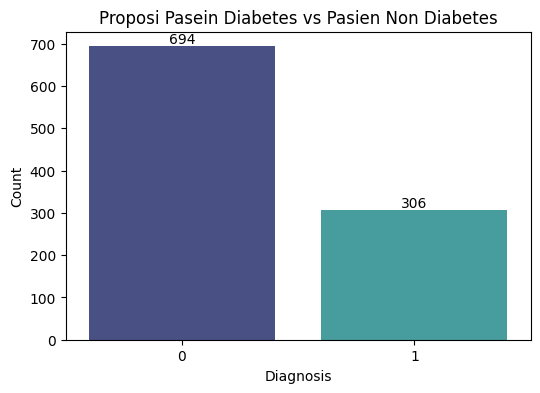

In [28]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Diagnosis', palette="mako")
for label in plt.gca().containers:
    plt.gca().bar_label(label)
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.title('Proposi Pasein Diabetes vs Pasien Non Diabetes')
plt.show()

Interpretasi :

Grafik batang (countplot) di atas menunjukkan distribusi atau perbandingan jumlah sampel data antara pasien dengan diagnosis diabetes dan non-diabetes. Berikut adalah interpretasi detailnya:

1. **Total Sampel**:
Jika dijumlahkan dari kedua kategori, total keseluruhan data dalam dataset ini adalah $694 + 306 = 1.000$ sampel.
2. **Kategori 0 (Non-Diabetes)**:
    * Batang sebelah kiri dengan warna biru tua merepresentasikan kategori `0` (biasanya menandakan kelas negatif atau non-diabetes).
    * Jumlah pasien pada kategori ini adalah **694 orang**, yang merupakan mayoritas dalam dataset ini (sekitar $69,4\%$ dari total keseluruhan data).


3. **Kategori 1 (Diabetes)**:
    * Batang sebelah kanan dengan warna hijau kebiruan merepresentasikan kategori `1` (menandakan kelas positif atau diabetes).
    * Jumlah pasien pada kategori ini adalah **306 orang** (sekitar $30,6\%$ dari total keseluruhan data).


4. **Implikasi untuk Pemodelan / Analisis Data**:
    * **Ketidakseimbangan Data (*Class Imbalance*)**: Terlihat jelas adanya ketidakseimbangan proporsi antara kelas 0 dan kelas 1 (rasio sekitar 7:3).
* **Catatan Penting**: Jika grafik ini digunakan untuk melatih model *Machine Learning* (klasifikasi), ketidakseimbangan kelas ini perlu diwaspadai agar model tidak bias terhadap kelas mayoritas (kategori 0). Teknik penanganan seperti *oversampling* (misal: SMOTE), *undersampling*, atau penyesuaian *class weight* mungkin diperlukan dalam tahap pemodelan selanjutnya.

### b)  Distribusi Glucose berdasarkan Diagnosis ( Histogram bertumpuk )



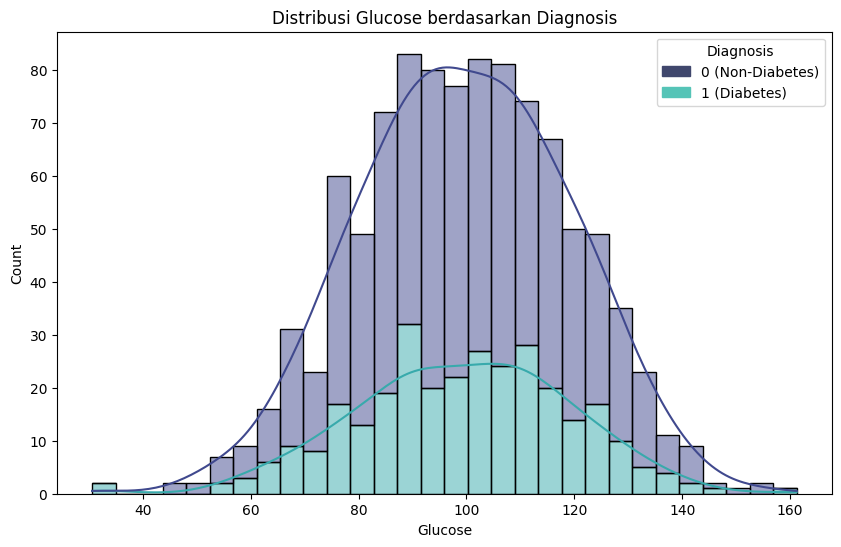

In [36]:
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 6))

# 1. Plot histogram dengan seaborn seperti biasa
sns.histplot(
    data=df,
    x='Glucose',
    hue='Diagnosis',
    bins=30,
    kde=True,
    multiple='stack',
    palette="mako"
)

plt.xlabel('Glucose')
plt.ylabel('Count')
plt.title('Distribusi Glucose berdasarkan Diagnosis')

# 2. Membuat legend secara manual agar pasti muncul
# Sesuaikan warna kode hex/nama warna dengan palette 'mako' (biru tua untuk 0, hijau kebiruan untuk 1)
patch_0 = mpatches.Patch(color='#40476d', label='0 (Non-Diabetes)')
patch_1 = mpatches.Patch(color='#55c4b7', label='1 (Diabetes)')

plt.legend(handles=[patch_0, patch_1], title='Diagnosis', loc='upper right')

plt.show()

Interpretasi :

Grafik *histogram* dengan kurva distribusi di atas menunjukkan perbandingan **Distribusi Glucose berdasarkan Diagnosis** (mengikuti warna dari visualisasi sebelumnya: biru tua untuk non-diabetes/0 dan hijau kebiruan untuk diabetes/1). Berikut adalah interpretasi detailnya:

1. **Pola Distribusi (Normal Distribution)**:
    * Kedua kelompok data (`Glucose` terhadap diagnosis) membentuk kurva lonceng (*bell-shaped curve*) yang mirip dengan **distribusi normal**.
    * Sebagian besar nilai konsentrasi glukosa terkonsentrasi di bagian tengah, dengan puncak frekuensi berada di sekitar rentang **90 hingga 110**.


2. **Perbandingan Antar-Kelas (Overlap)**:
    * **Kelompok Biru Tua (Non-Diabetes)** mendominasi hampir di seluruh rentang nilai glukosa karena jumlah total datanya yang memang lebih banyak secara keseluruhan.
    * **Kelompok Hijau Kebiruan (Diabetes)** juga tersebar di rentang yang hampir serupa, meskipun dengan frekuensi (*count*) yang lebih rendah di setiap bin/batangnya.
    * Terlihat adanya **irisan (*overlap*) yang cukup besar** antara kedua distribusi pada rentang nilai glukosa menengah (sekitar 80–120). Artinya, variabel `Glucose` saja memiliki area abu-abu di mana nilai glukosa tertentu dapat ditemukan pada kedua status diagnosis.


3. **Implikasi untuk Pemodelan / Fitur (*Feature Engineering*)**:
    * **Potensi Kekuatan Prediktif**: Meskipun ada *overlap*, secara visual puncak kurva kelompok hijau cenderung sedikit bergeser atau memiliki proporsi yang cukup signifikan pada rentang nilai tertentu, yang menjadikannya salah satu fitur prediktor yang kuat untuk klasifikasi.
    * **Normalisasi/Scaling**: Karena bentuk distribusinya mendekati normal, algoritma *Machine Learning* yang sensitif terhadap skala (seperti Logistic Regression, SVM, atau Neural Networks) akan merespons dengan baik jika variabel `Glucose` ini dinormalisasi atau di-standardisasi (misalnya menggunakan *StandardScaler*).

### c) Perbandingan BMI dan Age Per Diagnosis ( Boxplot )

/tmp/ipykernel_4028/835748486.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Diagnosis', y='BMI', ax=axes[0], palette="mako")
/tmp/ipykernel_4028/835748486.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Diagnosis', y='Age', ax=axes[1], palette="mako")


Text(0, 0.5, 'Age')

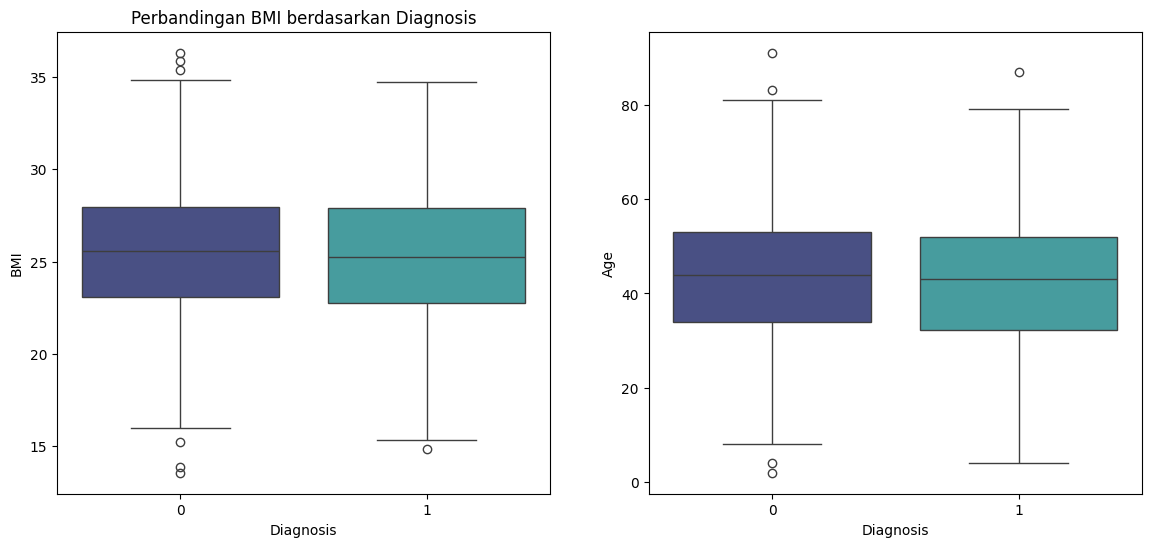

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


sns.boxplot(data=df, x='Diagnosis', y='BMI', ax=axes[0], palette="mako")
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('BMI')
axes[0].set_title('Perbandingan BMI berdasarkan Diagnosis')

sns.boxplot(data=df, x='Diagnosis', y='Age', ax=axes[1], palette="mako")
axes[1].set_xlabel('Diagnosis')
axes[1].set_ylabel('Age')

Interpretasi :

Grafik *box plot* di atas membandingkan dua fitur numerik utama, yaitu **BMI** (kiri) dan **Age / Usia** (kanan), dikelompokkan berdasarkan status `Diagnosis` (`0` untuk Non-Diabetes dan `1` untuk Diabetes).

Berikut adalah interpretasi detail dari kedua grafik tersebut:

**1. Grafik Perbandingan BMI berdasarkan Diagnosis (Kiri)**

* **Distribusi Median yang Mirip**: Garis tengah (*median*) untuk kelompok 0 dan kelompok 1 berada di sekitar angka yang hampir sama, yakni di kisaran 25–26. Ini menunjukkan bahwa nilai tengah BMI antara pasien diabetes dan non-diabetes tidak memiliki perbedaan yang mencolok secara visual.
* **Rentang dan Sebaran (*IQR*)**: Kotak (*interquartile range*) untuk kedua kelompok memiliki ukuran dan rentang batas atas/bawah yang hampir identik.
* **Outlier**: Pada kelompok `0` (Non-Diabetes), terdapat beberapa titik *outlier* di bagian atas (di atas angka 35) dan di bagian bawah (di bawah angka 15). Sementara kelompok `1` memiliki batas minimum *outlier* yang sedikit lebih rendah mendekati 15.

**2. Grafik Perbandingan Age berdasarkan Diagnosis (Kanan)**

* **Distribusi Usia yang Serupa**: Nilai *median* umur untuk kedua kelompok diagnosis berada di sekitar angka 43–44 tahun. Sebaran rentang kuartil pertama hingga ketiga (*box*) juga menunjukkan pola yang sangat mirip.
* **Outlier Usia**: Kelompok `0` memiliki beberapa titik *outlier* di atas usia 80 tahun (mencapai hampir 90 tahun), sedangkan kelompok `1` juga memiliki titik *outlier* di sekitar usia tersebut.


In [43]:
#hapus kolom object diagnosis_label
df.drop(columns=['Diagnosis_Label'])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
0,2,115.863387,56.410731,24.336736,94.385783,26.455940,0.272682,20,0
1,2,92.490122,70.615520,23.443591,138.652426,23.910167,0.665160,45,0
2,1,88.141469,63.262618,23.404364,149.358082,21.948250,0.676022,48,1
3,2,108.453101,67.793632,20.751580,108.751638,24.209304,0.289636,43,0
4,1,127.849443,94.725685,22.603078,25.269987,32.997477,0.601315,33,0
...,...,...,...,...,...,...,...,...,...
995,1,103.496355,41.059401,24.930299,43.675978,25.846062,0.455884,20,0
996,1,60.714150,64.082842,24.689064,111.562745,19.464280,0.250560,44,1
997,0,97.597727,64.122312,22.140339,108.138552,22.733052,0.761463,59,1
998,0,66.775137,55.908797,24.885274,219.521484,31.819187,0.382877,47,0


### d) Heatmap Korelasi anter Fitur

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1000 non-null   int64  
 1   Glucose                   1000 non-null   float64
 2   BloodPressure             1000 non-null   float64
 3   SkinThickness             1000 non-null   float64
 4   Insulin                   1000 non-null   float64
 5   BMI                       1000 non-null   float64
 6   DiabetesPedigreeFunction  1000 non-null   float64
 7   Age                       1000 non-null   int64  
 8   Diagnosis                 1000 non-null   int64  
 9   Diagnosis_Label           1000 non-null   object 
dtypes: float64(6), int64(3), object(1)
memory usage: 78.3+ KB


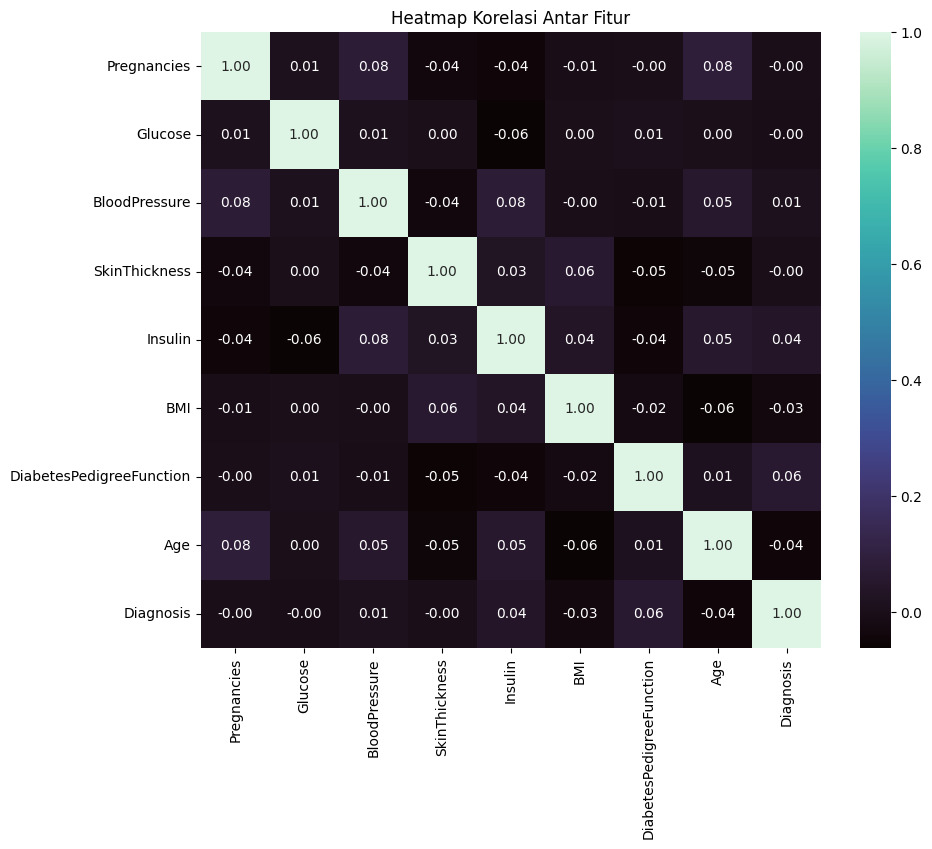

In [48]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='mako', fmt=".2f")
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

Interpretasi :

Poin utama: semua korelasi lemah

- Hampir semua nilai korelasi di luar diagonal mendekati 0 (antara -0.06 sampai 0.08). Artinya, antar fitur di dataset ini tidak ada hubungan linear yang kuat satu sama lain.

- Age vs Pregnancies: 0.08 → sedikit berkorelasi positif, masuk akal karena makin tua usia, biasanya makin banyak riwayat kehamilan

-  Diagnosis vs DiabetesPedigreeFunction: 0.06 → sedikit korelasi positif, sesuai logika (fungsi riwayat keturunan diabetes berkontribusi ke diagnosis)

- Diagnosis vs Age: -0.04 → nyaris tidak ada hubungan, agak aneh karena biasanya usia berpengaruh ke risiko diabetes

- BMI vs Age: -0.06

### e) Pairplot fitur Resiko utama berdasarkan Diabetes

In [52]:
risk_feature = ["Glucose", "BMI", "Age", "Insulin", "Diagnosis"]

In [53]:
plot_df = df[risk_feature].copy()

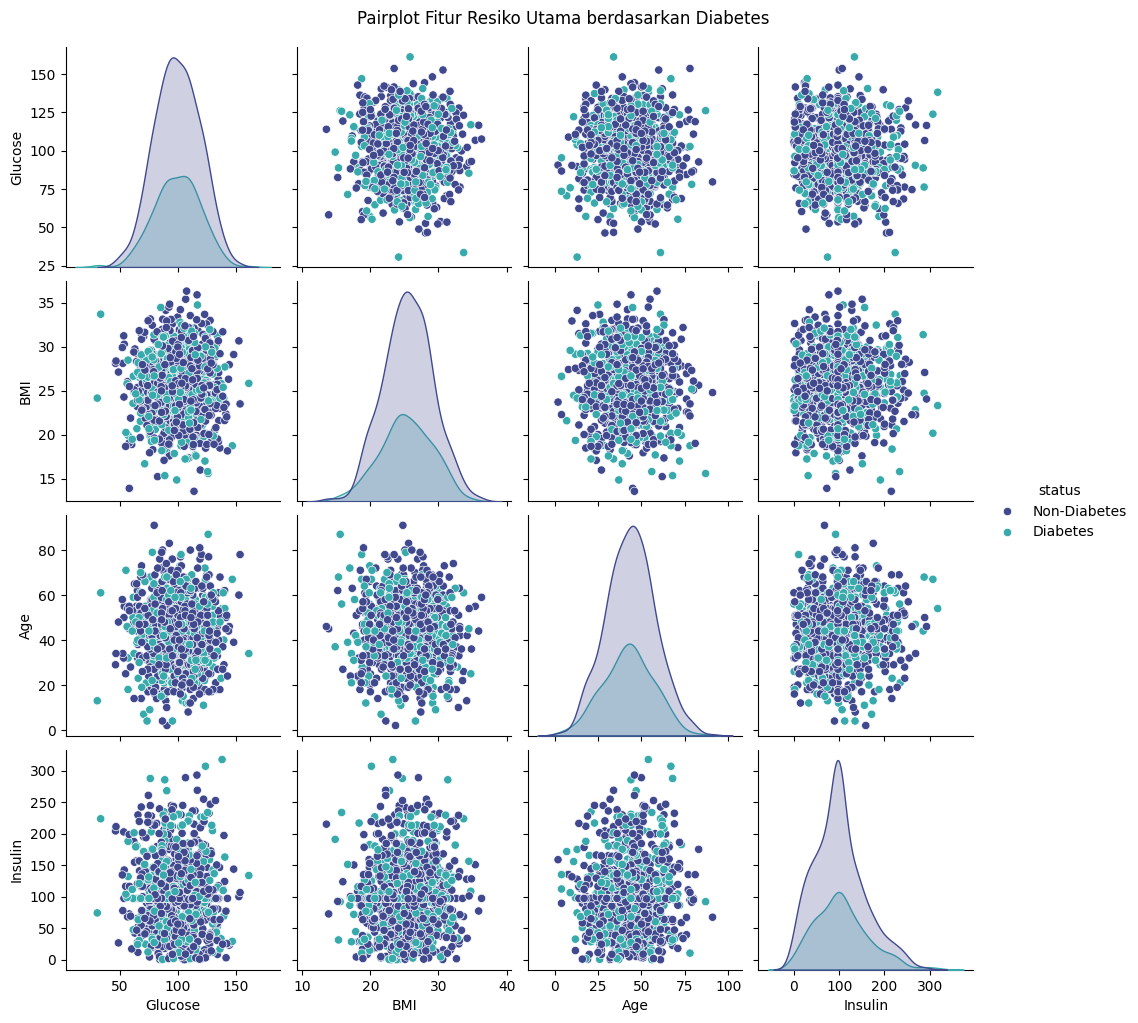

In [56]:
plot_df["status"] = plot_df["Diagnosis"].map({0: "Non-Diabetes", 1: "Diabetes"})
sns.pairplot(plot_df.drop(columns="Diagnosis"),
             hue="status",
             palette="mako")
plt.suptitle("Pairplot Fitur Resiko Utama berdasarkan Diabetes", y=1.02)
plt.show()

Interpretasi :

Pairplot ini menunjukkan sebaran 4 fitur utama (Glucose, BMI, Age, Insulin) dibandingkan status diabetes. Interpretasi sederhananya:

**Distribusi (diagonal grafik)**
- Semua fitur punya bentuk distribusi mirip antara kelompok Diabetes dan Non-Diabetes, cuma beda tinggi puncak (karena jumlah data Non-Diabetes lebih banyak)
- Tidak terlihat pemisahan yang jelas dan tajam antar dua kelompok

**Scatter plot (bagian lainnya)**
- Titik-titik biru (Non-Diabetes) dan hijau (Diabetes) **bercampur/overlap** di hampir semua kombinasi fitur
- Tidak ada garis pemisah yang jelas antara dua kelompok di kombinasi fitur manapun

**Kesimpulan sederhana:**
1. Tidak ada satu pasang fitur pun yang bisa memisahkan Diabetes vs Non-Diabetes secara jelas hanya dengan melihat scatter plot 2D
2. Ini konsisten dengan hasil heatmap korelasi sebelumnya — hubungan antar fitur dan status diabetes memang lemah/tidak linear
3. Artinya, untuk klasifikasi yang akurat, model butuh mempertimbangkan **kombinasi banyak fitur sekaligus** (bukan cuma 1-2 fitur), makanya model seperti Random Forest, XGBoost, atau Neural Network biasanya lebih cocok dibanding model linear sederhana

Interpretasi :

## Kesimpulan dan Insight

**1. Proporsi Diabetes vs Non-Diabetes (gambar termudah)**
- Data tidak seimbang: 694 Non-Diabetes vs 306 Diabetes (sekitar 70:30)
- Ini penting dicatat karena nanti saat modeling, imbalance ini bisa bikin model bias ke kelas mayoritas (Non-Diabetes). Perlu teknik seperti SMOTE, class_weight, atau evaluasi pakai F1-score/recall, bukan cuma accuracy

**2. Distribusi Glucose berdasarkan Diagnosis**
- Ini fitur yang paling "kelihatan" bedanya: kelompok Diabetes (hijau) polanya bergeser ke kanan dibanding Non-Diabetes (ungu)
- Artinya pasien diabetes cenderung punya kadar glucose lebih tinggi — sesuai logika medis
- Ini fitur paling menjanjikan sejauh ini buat membedakan dua kelompok

**3. Boxplot BMI & Age berdasarkan Diagnosis**
- BMI: median dan sebaran hampir sama antara diabetes vs non-diabetes → BMI sendirian kurang bisa membedakan
- Age: median juga mirip, cuma sedikit beda spread → sama, tidak terlalu diskriminatif sendirian
- Kedua fitur ini ada outlier tapi tidak menunjukkan pola pemisahan yang kuat

**4. Heatmap Korelasi**
- Mengonfirmasi temuan boxplot: korelasi Diagnosis dengan semua fitur individual lemah semua (di bawah 0.07)
- Bahkan Glucose yang tadi terlihat beda di histogram, korelasinya kecil juga di heatmap → artinya hubungannya mungkin ada tapi tidak murni linear

**5. Pairplot (paling kompleks)**
- Mengonfirmasi ulang: kombinasi 2 fitur apapun (Glucose-BMI, Glucose-Age, dst) tidak menghasilkan pemisahan visual yang jelas antara dua kelas
- Titik-titik tetap bercampur di semua kombinasi

**Kesimpulan keseluruhan (benang merah dari 5 EDA ini):**
- Data imbalanced → perlu penanganan khusus saat modeling
- Glucose adalah fitur paling berpotensi sebagai prediktor kuat (secara univariate)
- BMI dan Age individually lemah, tapi bisa saja berkontribusi kalau dikombinasikan dengan fitur lain
- Tidak ada fitur atau pasangan fitur yang bisa memisahkan kelas secara jelas secara visual → hubungan fitur-target kemungkinan besar **non-linear dan multivariat**
- Ini mengarahkan pilihan model ke arah tree-based (Random Forest, XGBoost, LightGBM) atau model yang mampu menangkap interaksi antar fitur, dibanding model linear seperti Logistic Regression polos

Berikut insight dan rekomendasi bisnis berdasarkan temuan EDA di atas:

## Insight Bisnis

**1. Skrining berbasis Glucose bisa jadi early-warning tool murah**
- Glucose adalah fitur dengan sinyal pembeda paling jelas secara visual
- Bisnis (klinik, asuransi kesehatan, program wellness perusahaan) bisa menjadikan tes glucose sederhana sebagai **tahap skrining awal** sebelum tes lanjutan yang lebih mahal (HbA1c, dll)
- Cocok untuk program preventive health check yang murah dan cepat

**2. Data imbalance mencerminkan realita populasi — bukan masalah, tapi peluang**
- Rasio 70:30 (Non-Diabetes:Diabetes) mendekati prevalensi riil di banyak populasi berisiko
- Insight bisnis: sekitar 30% populasi yang diperiksa berpotensi diabetes — ini bisa dipakai buat **estimasi kebutuhan sumber daya** (jumlah dokter, obat, kapasitas klinik) kalau program skrining diperluas ke populasi lebih besar

**3. Tidak ada "silver bullet" satu fitur — butuh pendekatan holistik**
- Karena BMI, Age tidak cukup diskriminatif sendirian, keputusan bisnis (misal: siapa yang perlu diprioritaskan untuk cek lanjutan) **tidak boleh hanya berdasar satu indikator** seperti "usia di atas 40" atau "BMI tinggi"
- Rekomendasi: bangun sistem **skoring risiko multivariat** (pakai model ML) daripada aturan sederhana manual, karena polanya kompleks dan non-linear

**4. Model prediktif bisa dipakai untuk triase, bukan diagnosis final**
- Karena tidak ada pemisahan sempurna antar kelas, model sebaik apapun tetap akan punya overlap/uncertainty
- Rekomendasi implementasi: gunakan model sebagai **alat bantu triase** (menentukan siapa yang perlu prioritas konsultasi dokter atau tes lanjutan), bukan sebagai pengganti diagnosis dokter
- Ini penting untuk positioning produk — hindari klaim "mendiagnosis diabetes", lebih aman diposisikan sebagai "risk assessment tool"

**5. Potensi produk/fitur turunan**
- **Dashboard risk-stratification** untuk klinik: pasien dikelompokkan Low/Medium/High risk berdasarkan kombinasi Glucose+BMI+Age+fitur lain
- **Personalized health recommendation**: pasien dengan Glucose tinggi tapi belum diabetes bisa diarahkan ke program preventif (diet, olahraga) sebelum kondisi memburuk
- Fitur ini punya nilai jual ke asuransi kesehatan (mengurangi klaim jangka panjang) atau ke platform kesehatan digital (meningkatkan engagement lewat personalized insight)

**Catatan penting:** karena kelas Diabetes ini minoritas (~30%) tapi biaya kesalahan (false negative — pasien diabetes tidak terdeteksi) jauh lebih mahal daripada false positive, rekomendasikan **prioritaskan recall/sensitivity** di atas accuracy saat membangun model produksinya nanti.